Best objective: 80 (0.08)
Objective bound: 84
Minimum objective: 80
Cache sizes - Greedy: 2554, Lickety: 4788, Trie: 0, Trie cache: OFF
Minimum objective: 80
Rashomon set size: 33
Histogram entries: [(80, 12), (81, 8), (82, 5), (84, 8)]
Objective = 80, Count = 12
Objective = 81, Count = 8
Objective = 82, Count = 5
Objective = 84, Count = 8

Total Rashomon trees: 33

Tree 0
Objective (raw):      80
Objective (normalized): 0.080000

Predictions from tree 0 (first 10 samples):
[1 0 0 0 0 0 1 1 1 1]
Training accuracy (tree 0): 1.0000

Tree 0 has 8 leaves.
All root-to-leaf paths:
[+2, +3, +14] -> 0
[+2, +3, -14] -> 1
[+2, -3, +14] -> 1
[+2, -3, -14] -> 0
[-2, +3, +14] -> 1
[-2, +3, -14] -> 0
[-2, -3, +14] -> 0
[-2, -3, -14] -> 1


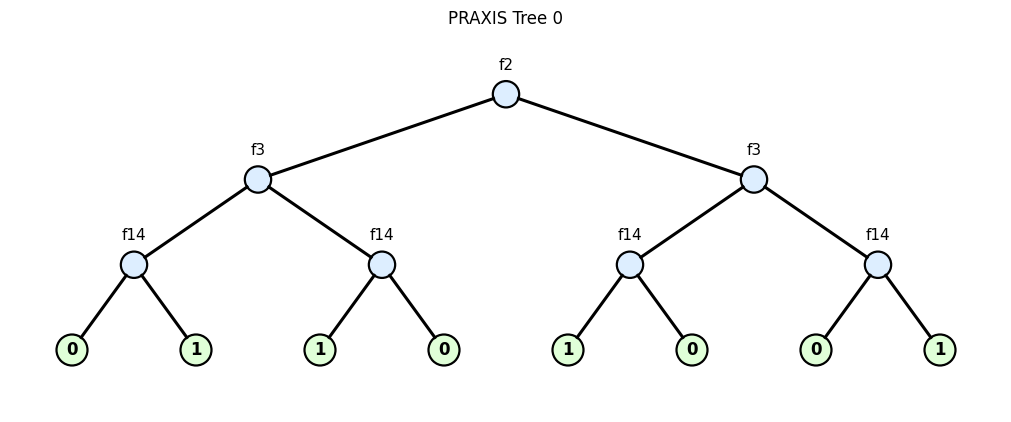

Tree 32
Objective (raw):      84
Objective (normalized): 0.084000

Predictions from tree 32 (first 10 samples):
[1 0 0 0 0 0 1 1 1 1]
Training accuracy (tree 32): 0.9960

Tree 32 has 8 leaves.
All root-to-leaf paths:
[+14, +3, +12] -> 0
[+14, +3, -12] -> 1
[+14, -3, +2] -> 1
[+14, -3, -2] -> 0
[-14, +3, +2] -> 1
[-14, +3, -2] -> 0
[-14, -3, +2] -> 0
[-14, -3, -2] -> 1


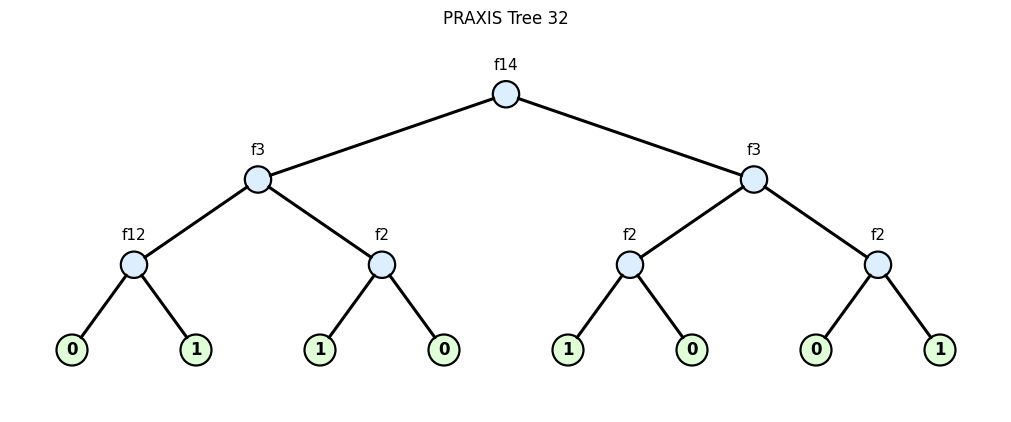


[Dimensionality] Number of trees in all_preds_list: 33
[Dimensionality] Shape of first tree's prediction vector: (1000,)

[Dimensionality] Stacked prediction matrix shape (n_trees, n_samples): (33, 1000)
Majority-vote predictions (first 10 samples):
[1 0 0 0 0 0 1 1 1 1]


In [5]:
import numpy as np
from praxis import PRAXIS
import matplotlib.pyplot as plt

def accuracy(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    return (y_true == y_pred).mean()

n_samples = 1000
n_features = 10

rng = np.random.default_rng(0)

X = (rng.random((n_samples, n_features)) > 0.5).astype(np.uint8)

# label: odd/even parity of first 4 features
three_sum = X[:, 0] + X[:, 1] + X[:, 2] + X[:, 3]
y = (three_sum % 2).astype(int)

# extra feature for interest: 1 if x1 + x2 is even, 0 otherwise
sum_01 = X[:, 0] + X[:, 1]
even_01 = ((sum_01 % 2) == 0).astype(np.uint8)

# make 4 noisy copies of the first 4 columns
# each entry is flipped with probability 1/100
base_four = X[:, :4].copy()
flip_mask = (rng.random((n_samples, 4)) < 0.01).astype(np.uint8)  # 1 with prob 0.01, else 0
noisy_four = base_four ^ flip_mask  # XOR to flip bits where flip_mask == 1

# append these extra features
X = np.hstack([X, noisy_four, even_01[:, None]])


model = PRAXIS()

model.fit(
    X, y,
    lambda_reg=0.01,        # sparsity penalty - recommended
    depth_budget=5,         # max tree depth as defined by number of splits along any path
    rashomon_mult=0.05,     # rashomon bound: 5% worse than initial oracle objective
    # optional parameters (default is sufficient)
    multiplicative_slack=0, # extra slack factor 
    key_mode="hash",        # "hash" for memory savings at an astronomically low change of error or "exact"
    trie_cache_enabled=False, # not recommended with hash
    lookahead_k=1, # 1 = LicketySPLIT oracle, 0 = greedy, >1 higher-tiered oracles
)

print("Minimum objective:", model.get_min_objective())
print("Rashomon set size:", model.count_trees())

hist = model.get_root_histogram()
print("Histogram entries:", hist)

for obj, cnt in hist:
    print(f"Objective = {obj}, Count = {cnt}")

# we will inspect the first and last trees
num_trees = model.count_trees()
tree_indices = [0, num_trees - 1]

print(f"\nTotal Rashomon trees: {num_trees}\n")

for tree_idx in tree_indices:
    print("=" * 60)
    print(f"Tree {tree_idx}")
    
    obj_raw, obj_norm = model.get_tree_objective(tree_idx)
    print(f"Objective (raw):      {obj_raw}")
    print(f"Objective (normalized): {obj_norm:.6f}")

    preds_i = model.get_predictions(tree_idx, X)
    print(f"\nPredictions from tree {tree_idx} (first 10 samples):")
    print(preds_i[:10])
    
    acc_i = accuracy(y, preds_i)
    print(f"Training accuracy (tree {tree_idx}): {acc_i:.4f}")

    paths_str, preds = model.get_tree_paths_str(tree_idx)
    print(f"\nTree {tree_idx} has {len(paths_str)} leaves.")

    print("All root-to-leaf paths:")
    for s, p in zip(paths_str, preds):
        print(s, "->", p)

    model.plot_tree(tree_idx, title=f"PRAXIS Tree {tree_idx}", show=True)
    
# list-of-vectors version
all_preds_list = model.get_all_predictions(X, stack=False)
print(f"\n[Dimensionality] Number of trees in all_preds_list: {len(all_preds_list)}")
if len(all_preds_list) > 0:
    print("[Dimensionality] Shape of first tree's prediction vector:",
          all_preds_list[0].shape)

# stacked matrix version
all_preds_mat = model.get_all_predictions(X, stack=True)
print("\n[Dimensionality] Stacked prediction matrix shape (n_trees, n_samples):",
      all_preds_mat.shape)

majority_vote = (all_preds_mat.mean(axis=0) >= 0.5).astype(np.uint8)
print("Majority-vote predictions (first 10 samples):")
print(majority_vote[:10])


Best objective: 600Minimum objective: 600
Rashomon set size: 4464
Histogram entries: [(600, 360), (610, 128), (611, 52), (612, 256), (613, 128), (614, 564), (615, 52), (616, 156), (618, 104), (621, 16), (622, 188), (623, 72), (624, 448), (625, 198), (626, 618), (627, 238), (628, 382), (629, 236), (630, 268)]
Objective = 600, Count = 360
Objective = 610, Count = 128
Objective = 611, Count = 52
Objective = 612, Count = 256
Objective = 613, Count = 128
Objective = 614, Count = 564
Objective = 615, Count = 52
Objective = 616, Count = 156
Objective = 618, Count = 104
Objective = 621, Count = 16
Objective = 622, Count = 188
Objective = 623, Count = 72
Objective = 624, Count = 448
Objective = 625, Count = 198
Objective = 626, Count = 618
Objective = 627, Count = 238
Objective = 628, Count = 382
Objective = 629, Count = 236
Objective = 630, Count = 268

Total Rashomon trees: 4464

Tree 0
Objective (raw):      600
Objective (normalized): 0.060000

Predictions from tree 0 (first 10 samples):
[1 

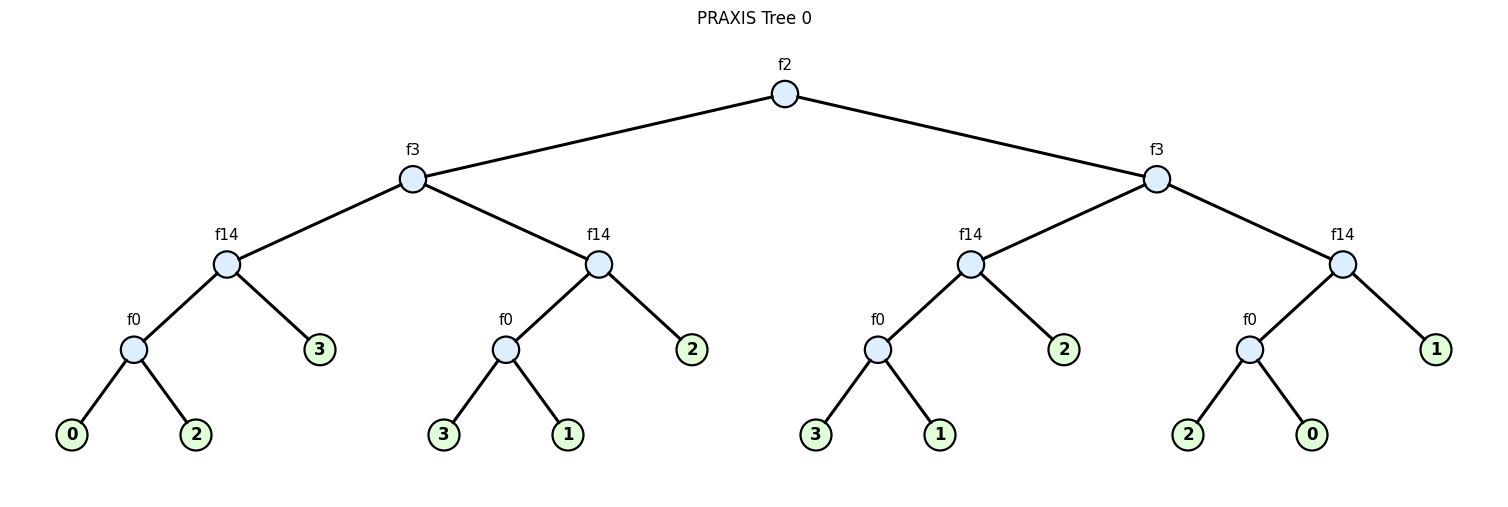

Tree 4463
Objective (raw):      630
Objective (normalized): 0.063000

Predictions from tree 4463 (first 10 samples):
[1 2 2 2 2 2 1 3 3 3]

Tree 4463 has 12 leaves.
All root-to-leaf paths:
[+14, +3, +1, +2] -> 0
[+14, +3, +1, -2] -> 3
[+14, +3, -1, +12] -> 2
[+14, +3, -1, -12] -> 1
[+14, -3, +2, +1] -> 3
[+14, -3, +2, -1] -> 1
[+14, -3, -2, +11] -> 2
[+14, -3, -2, -11] -> 0
[-14, +3, +2] -> 3
[-14, +3, -2] -> 2
[-14, -3, +2] -> 2
[-14, -3, -2] -> 1


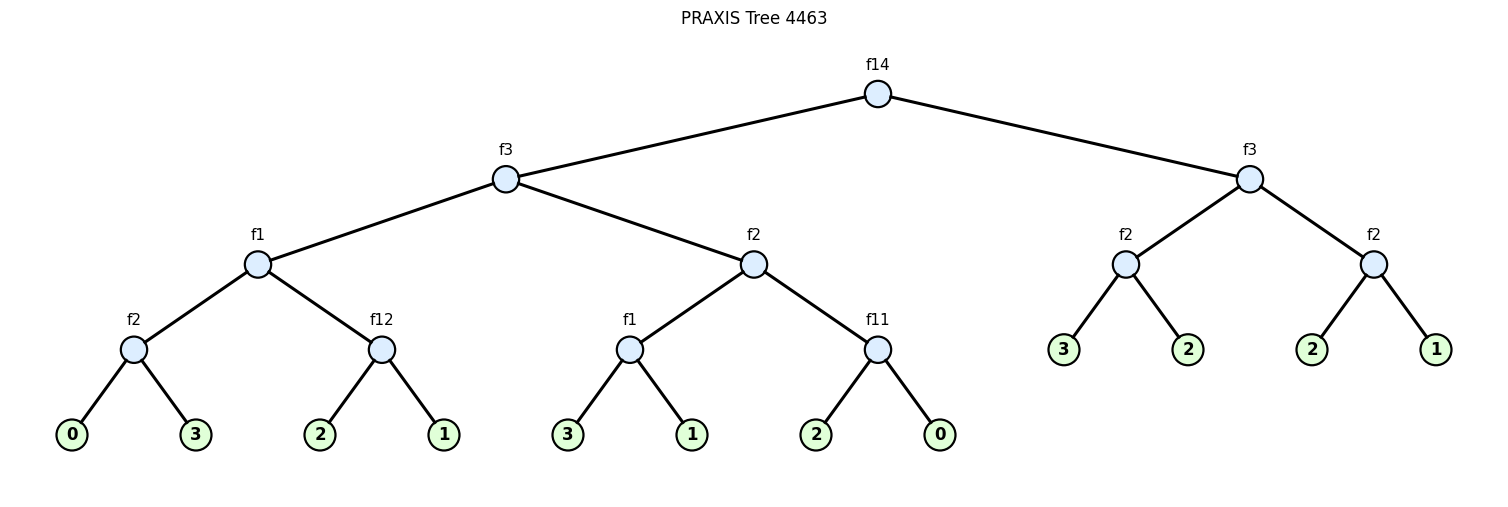


[Dimensionality] Number of trees in all_preds_list: 4464
[Dimensionality] Shape of first tree's prediction vector: (10000,)

[Dimensionality] Stacked prediction matrix shape (n_trees, n_samples): (4464, 10000)
Majority-vote predictions (first 10 samples):
[1 2 2 2 2 2 1 3 3 3]


In [6]:
import numpy as np
from praxis import PRAXIS
import matplotlib.pyplot as plt

n_samples = 10000
n_features = 10

rng = np.random.default_rng(0)

X = (rng.random((n_samples, n_features)) > 0.5).astype(np.uint8)

# label: 4-parity of first 4 features
three_sum = X[:, 0] + X[:, 1] + X[:, 2] + X[:, 3]
y = (three_sum % 4).astype(int)

# extra feature for interest: 1 if x1 + x2 is even, 0 otherwise
sum_01 = X[:, 0] + X[:, 1]
even_01 = ((sum_01 % 2) == 0).astype(np.uint8)

# make 4 noisy copies of the first 4 columns
# each entry is flipped with probability 1/100
base_four = X[:, :4].copy()
flip_mask = (rng.random((n_samples, 4)) < 0.01).astype(np.uint8)  # 1 with prob 0.01, else 0
noisy_four = base_four ^ flip_mask  # XOR to flip bits where flip_mask == 1

# append these extra features
X = np.hstack([X, noisy_four, even_01[:, None]])


model = PRAXIS()

model.fit(
    X, y,
    lambda_reg=0.005,        # sparsity penalty - recommended
    depth_budget=6,         # max tree depth as defined by number of splits along any path
    rashomon_mult=0.05,     # rashomon bound: 5% worse than initial oracle objective
    # optional parameters (default is sufficient)
    multiplicative_slack=0, # extra slack factor 
    key_mode="hash",        # "hash" for memory savings at an astronomically low change of error or "exact"
    trie_cache_enabled=False, # not recommended with hash
    lookahead_k=5, # 1 = LicketySPLIT oracle, 0 = greedy, >1 higher-tiered oracles
)

print("Minimum objective:", model.get_min_objective())
print("Rashomon set size:", model.count_trees())

hist = model.get_root_histogram()
print("Histogram entries:", hist)

for obj, cnt in hist:
    print(f"Objective = {obj}, Count = {cnt}")

# we will inspect the first and last trees
num_trees = model.count_trees()
tree_indices = [0, num_trees - 1]

print(f"\nTotal Rashomon trees: {num_trees}\n")

for tree_idx in tree_indices:
    print("=" * 60)
    print(f"Tree {tree_idx}")
    
    obj_raw, obj_norm = model.get_tree_objective(tree_idx)
    print(f"Objective (raw):      {obj_raw}")
    print(f"Objective (normalized): {obj_norm:.6f}")

    preds_i = model.get_predictions(tree_idx, X)
    print(f"\nPredictions from tree {tree_idx} (first 10 samples):")
    print(preds_i[:10])

    paths_str, preds = model.get_tree_paths_str(tree_idx)
    print(f"\nTree {tree_idx} has {len(paths_str)} leaves.")

    print("All root-to-leaf paths:")
    for s, p in zip(paths_str, preds):
        print(s, "->", p)

    model.plot_tree(tree_idx, title=f"PRAXIS Tree {tree_idx}")

# list-of-vectors version
all_preds_list = model.get_all_predictions(X, stack=False)
print(f"\n[Dimensionality] Number of trees in all_preds_list: {len(all_preds_list)}")
if len(all_preds_list) > 0:
    print("[Dimensionality] Shape of first tree's prediction vector:",
          all_preds_list[0].shape)

# stacked matrix version
all_preds_mat = model.get_all_predictions(X, stack=True)
print("\n[Dimensionality] Stacked prediction matrix shape (n_trees, n_samples):",
      all_preds_mat.shape)

majority_vote = all_preds_mat.mean(axis=0).round().astype(np.uint8)
print("Majority-vote predictions (first 10 samples):")
print(majority_vote[:10])


Best objective: 
RID mean_sub_mr (per feature):
  f0: 0.081962
  f1: 0.082041
  f2: 0.482874
  f3: 0.440909
  f4: 0.000000
  f5: 0.000000
  f6: 0.000000
  f7: 0.000000
  f8: 0.000000
  f9: 0.000000
 f10: 0.045647
 f11: 0.040463
 f12: 0.013635
 f13: 0.058602
 f14: 0.495889
120 (0.12)
Objective bound: 121
Minimum objective: 120
Cache sizes - Greedy: 2022, Lickety: 3160, Trie: 0, Trie cache: OFF
Finished RID bootstrap: 1 / 20 with 6047 trees
Best objective: 120 (0.12)
Objective bound: 121
Minimum objective: 120
Cache sizes - Greedy: 1994, Lickety: 3202, Trie: 0, Trie cache: OFF
Finished RID bootstrap: 2 / 20 with 7314 trees
Best objective: 120 (0.12)
Objective bound: 121
Minimum objective: 120
Cache sizes - Greedy: 2033, Lickety: 3276, Trie: 0, Trie cache: OFF
Finished RID bootstrap: 3 / 20 with 4157 trees
Best objective: 120 (0.12)
Objective bound: 121
Minimum objective: 120
Cache sizes - Greedy: 2055, Lickety: 3213, Trie: 0, Trie cache: OFF
Finished RID bootstrap: 4 / 20 with 3930 trees

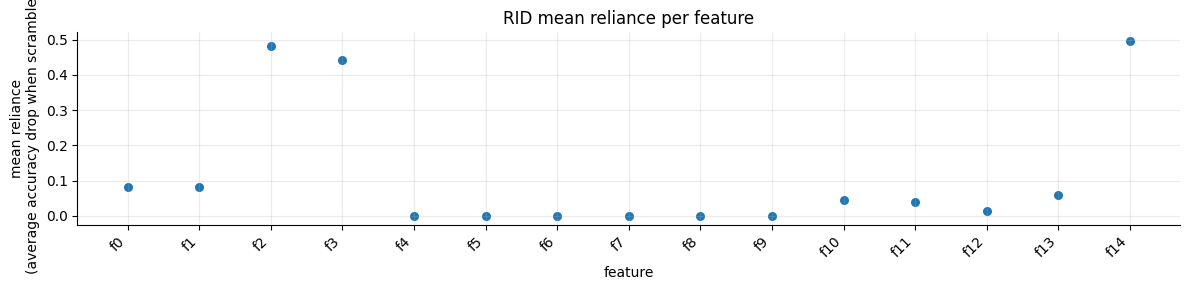

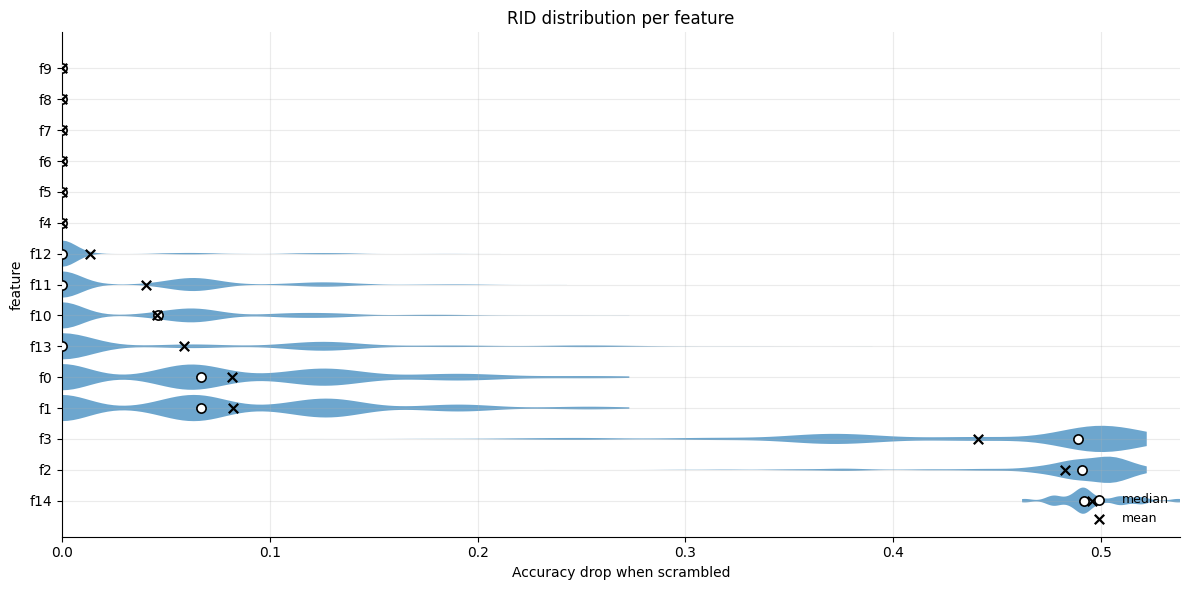

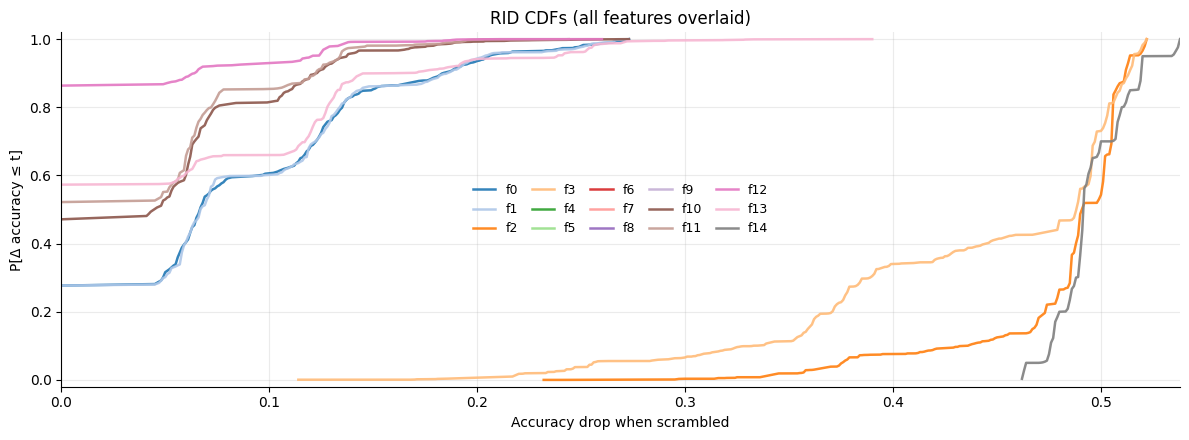

(<Figure size 1200x450 with 1 Axes>,
 <Axes: title={'center': 'RID CDFs (all features overlaid)'}, xlabel='Accuracy drop when scrambled', ylabel='P[Δ accuracy ≤ t]'>)

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from praxis import PRAXIS

n_samples = 1000
n_features = 10
rng = np.random.default_rng(0)

X = (rng.random((n_samples, n_features)) > 0.5).astype(np.uint8)

three_sum = X[:, 0] + X[:, 1] + X[:, 2] + X[:, 3]
y = (three_sum % 4).astype(int)

sum_01 = X[:, 0] + X[:, 1]
even_01 = ((sum_01 % 2) == 0).astype(np.uint8)

base_four = X[:, :4].copy()
flip_mask = (rng.random((n_samples, 4)) < 0.01).astype(np.uint8)
noisy_four = base_four ^ flip_mask

X = np.hstack([X, noisy_four, even_01[:, None]])

feature_names = [f"f{j}" for j in range(X.shape[1])]

model = PRAXIS()
rid_out = model.compute_rid(
    X,
    y,
    n_boot=20,
    lambda_reg=0.01,
    depth_budget=5,
    rashomon_mult=0.01,
    lookahead_k=1,
    seed=0,
    memory_efficient=False,
    binning_map=None,
)

mean = np.asarray(rid_out["mean_sub_mr"], dtype=float)
print("\nRID mean_sub_mr (per feature):")
for j, m in enumerate(mean):
    print(f"{feature_names[j]:>4}: {m:.6f}")

model.rid_plot_mean(feature_names=feature_names, figsize=(12, 3))
model.rid_plot_violin(feature_names=feature_names, figsize=(12, 6), samples_per_feature=4000, seed=123)
model.rid_plot_cdfs(feature_names=feature_names, figsize=(12, 4.5), legend_ncol=5, legend_fontsize=9)


Best objective: 1674Minimum objective: 1674
Rashomon set size: (0.337092)
Objective bound: 1724
Minimum objective: 1674
Cache sizes - Greedy: 16324, Lickety: 89581, Trie: 0, Trie cache: OFF
 227184388

Root histogram (objective_int, count):
  1674: 28
  1679: 28
  1680: 40
  1682: 14
  1683: 14
  1684: 236
  1685: 200
  1686: 484
  1687: 198
  1688: 576
  1689: 5918
  1690: 858
  1691: 672
  1692: 739
  1693: 1003
  1694: 5862
  1695: 8417
  1696: 2907
  1697: 5411
  1698: 6826
  1699: 42114
  1700: 39170
  1701: 85772
  1702: 47433
  1703: 105731
  1704: 628734
  1705: 165198
  1706: 140776
  1707: 166504
  1708: 214408
  1709: 661747
  1710: 1024800
  1711: 569136
  1712: 829888
  1713: 1090963
  1714: 4303611
  1715: 4307246
  1716: 8756152
  1717: 5998514
  1718: 11318485
  1719: 48621111
  1720: 18440530
  1721: 16742707
  1722: 20432197
  1723: 25579858
  1724: 56831172

Tree 0
  Objective (raw):        1674
  Objective (normalized): 0.337092
  Leaves: 5


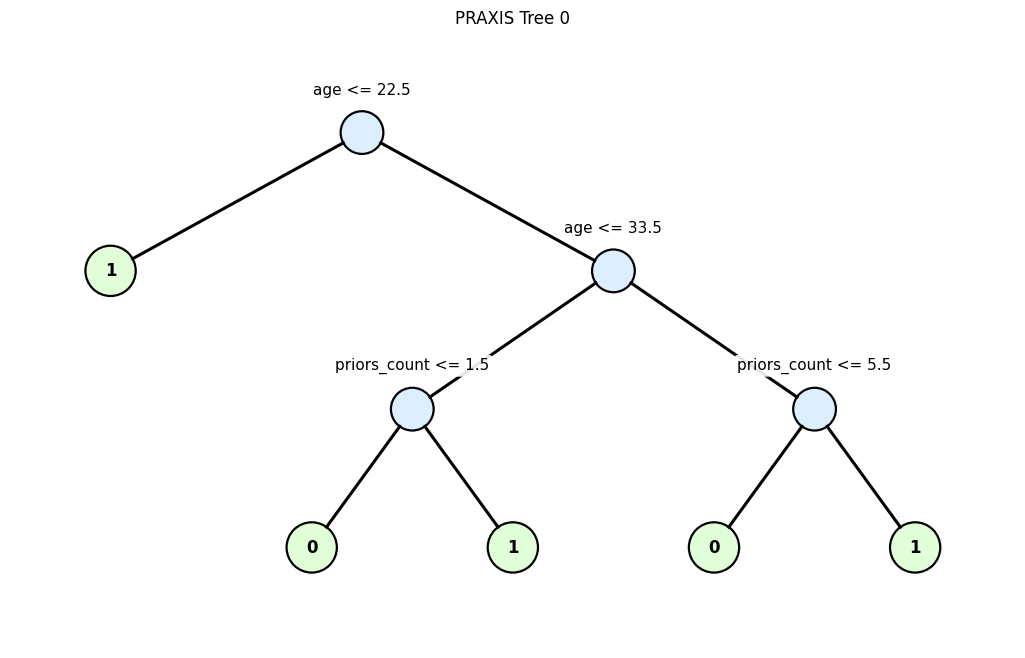


Tree 227184387
  Objective (raw):        1724
  Objective (normalized): 0.347161
  Leaves: 9


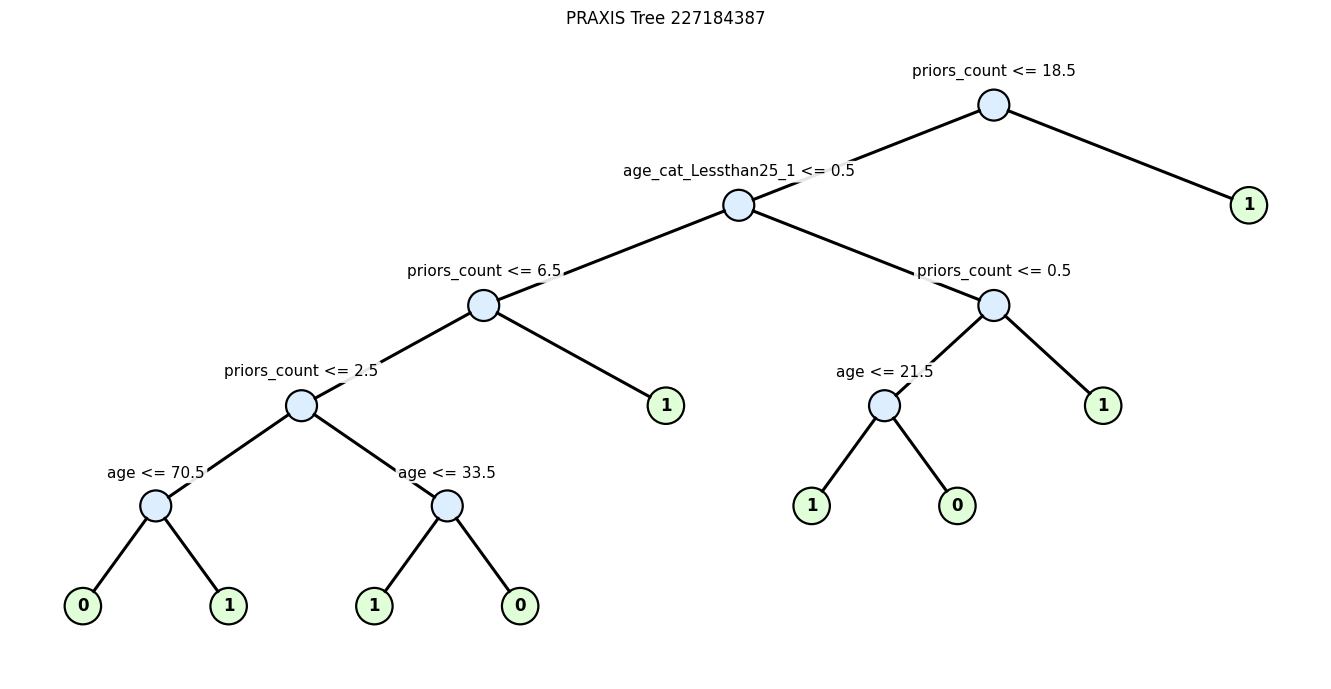

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from praxis import PRAXIS, ThresholdGuessBinarizer

df = pd.read_csv("compas_binarized.csv")

feature_names = df.columns[:-1].tolist()
X = df.iloc[:, :-1].to_numpy(dtype=np.uint8)
y = df.iloc[:, -1].to_numpy(dtype=int)

model = PRAXIS()
model.fit(
    X, y,
    lambda_reg=0.003,
    depth_budget=5,
    rashomon_mult=0.03,
    multiplicative_slack=0.0,
    key_mode="hash",
    trie_cache_enabled=False,
    lookahead_k=1,
)

print("Minimum objective:", model.get_min_objective())
num_trees = model.count_trees()
print("Rashomon set size:", num_trees)

hist = model.get_root_histogram()
print("\nRoot histogram (objective_int, count):")
for obj, cnt in hist:
    print(f"  {obj}: {cnt}")

tree_indices = [0, num_trees - 1] if num_trees > 1 else [0]

for tree_idx in tree_indices:
    obj_raw, obj_norm = model.get_tree_objective(tree_idx)
    print("\n" + "=" * 60)
    print(f"Tree {tree_idx}")
    print(f"  Objective (raw):        {obj_raw}")
    print(f"  Objective (normalized): {obj_norm:.6f}")

    paths_str, preds = model.get_tree_paths_str(tree_idx)
    print(f"  Leaves: {len(paths_str)}")

    model.plot_tree(tree_idx, feature_names=feature_names, figsize=(20, 8),title=f"PRAXIS Tree {tree_idx}")



Best objective: 1603Minimum objective: 1593
Rashomon set size: 36604486

Root histogram (objective_int, count):
  1593: 824
  1594: 1172
  1595: 1560
  1596: 2336
  1597: 11544
  1598: 210380
  1599: 311876
  1600: 518888
  1601: 864492
  1602: 3378444
  1603: 31302970

Tree 0
  Objective (raw):        1593
  Objective (normalized): 0.320781
  Leaves: 10
 (0.322795)
Objective bound: 1603
Minimum objective: 1593
Cache sizes - Greedy: 605667, Lickety: 302616, Trie: 0, Trie cache: OFF


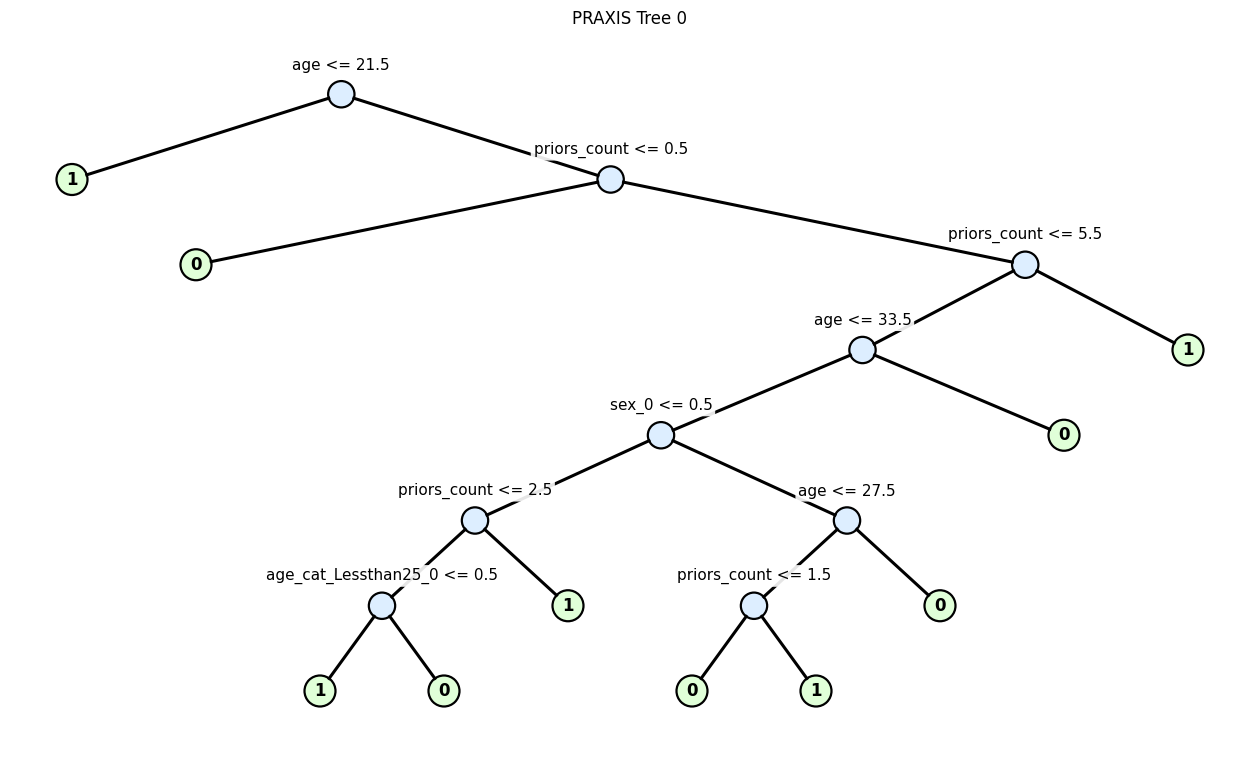


Tree 36604485
  Objective (raw):        1603
  Objective (normalized): 0.322795
  Leaves: 12


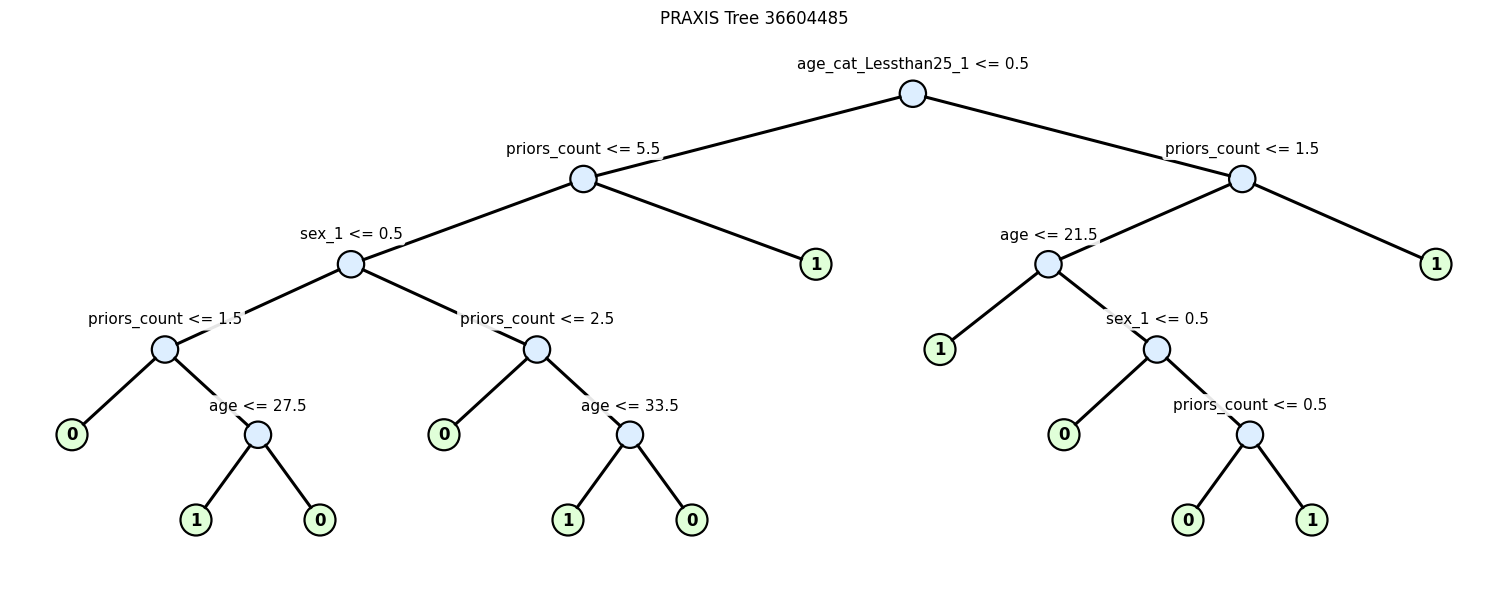

In [9]:
# deeper trees
model = PRAXIS()
model.fit(
    X, y,
    lambda_reg=0.001,
    depth_budget=10,
    rashomon_mult=0.00,
    multiplicative_slack=0.0,
    key_mode="hash",
    trie_cache_enabled=False,
    lookahead_k=1,
)

print("Minimum objective:", model.get_min_objective())
num_trees = model.count_trees()
print("Rashomon set size:", num_trees)

hist = model.get_root_histogram()
print("\nRoot histogram (objective_int, count):")
for obj, cnt in hist:
    print(f"  {obj}: {cnt}")

tree_indices = [0, num_trees - 1] if num_trees > 1 else [0]

for tree_idx in tree_indices:
    obj_raw, obj_norm = model.get_tree_objective(tree_idx)
    print("\n" + "=" * 60)
    print(f"Tree {tree_idx}")
    print(f"  Objective (raw):        {obj_raw}")
    print(f"  Objective (normalized): {obj_norm:.6f}")

    paths_str, preds = model.get_tree_paths_str(tree_idx)
    print(f"  Leaves: {len(paths_str)}")

    model.plot_tree(tree_idx, feature_names=feature_names, figsize=(14, 6), title=f"PRAXIS Tree {tree_idx}")


Single-tree objective: 
Tree 0
  Objective (raw):        1603
  Objective (normalized): 0.322795
1603 (0.322795)
  preds[:10]: [0 1 0 1 1 0 0 0 0 0]
  Training accuracy: 0.6892871526379379
  Leaves: 12


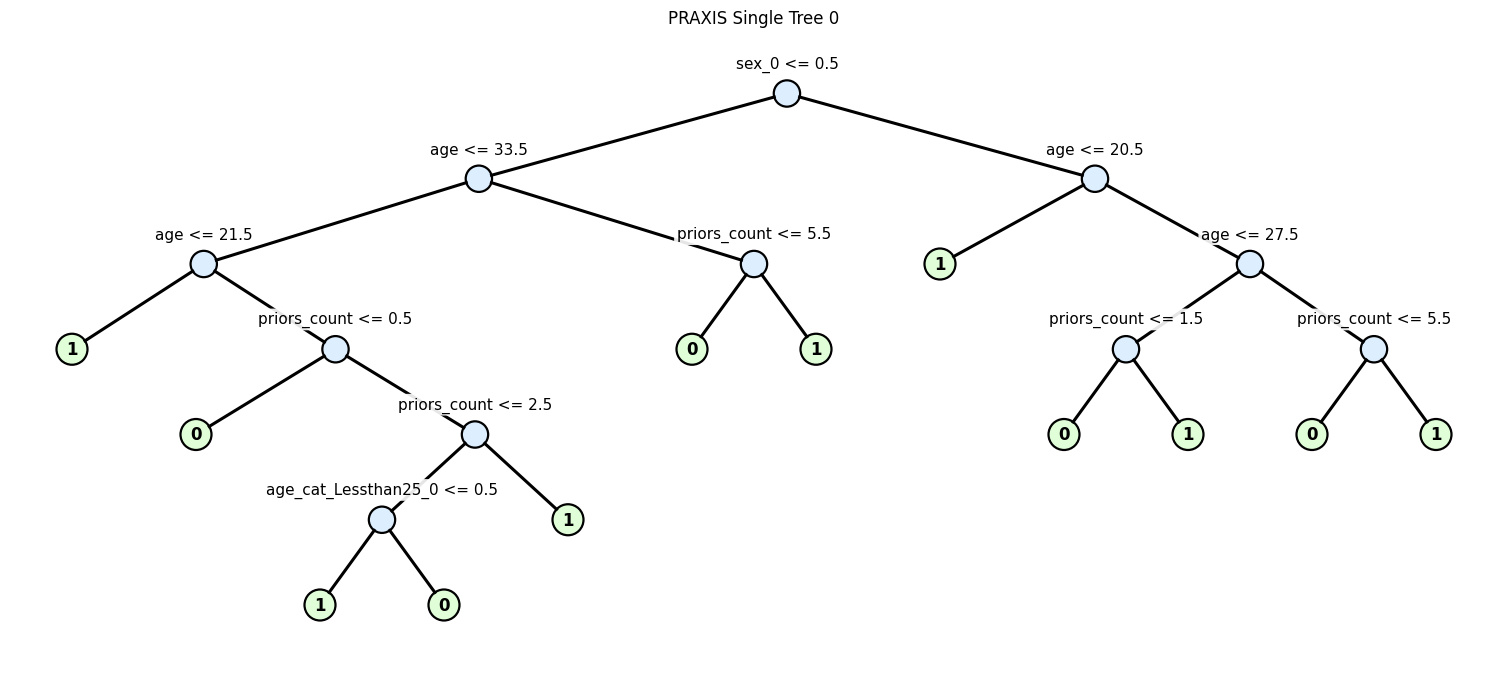

(<Figure size 1920x980 with 1 Axes>,
 <Axes: title={'center': 'PRAXIS Single Tree 0'}>)

In [10]:
import numpy as np

def accuracy(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    return (y_true == y_pred).mean()

# deeper single-tree version
model = PRAXIS()
model.fit(
    X, y,
    lambda_reg=0.001,
    depth_budget=10,
    key_mode="hash",
    trie_cache_enabled=False,
    lookahead_k=1, # in single tree mode, lookahead_k specifies the decision tree algorithm: 0 for greedy, 1 for LicketySPLIT, and 2+ for generalizations of LicketySPLIT. lookahead_k=d-1 is optimal.
    rashomon_mode=False, # single tree mode
)

tree_idx = 0 # only one tree in single-tree mode

obj_raw, obj_norm = model.get_tree_objective(tree_idx)
print("\n" + "=" * 60)
print(f"Tree {tree_idx}")
print(f"  Objective (raw):        {obj_raw}")
print(f"  Objective (normalized): {obj_norm:.6f}")

# predictions + accuracy
y_hat = model.get_predictions(tree_idx, X).astype(np.uint8)
print("  preds[:10]:", y_hat[:10])
print("  Training accuracy:", accuracy(y, y_hat))

# paths + plot
paths_str, preds = model.get_tree_paths_str(tree_idx)
print(f"  Leaves: {len(paths_str)}")

model.plot_tree(tree_idx, feature_names=feature_names, figsize=(14, 6), title=f"PRAXIS Single Tree {tree_idx}")


{0: [0, 1, 2, 3, 4, 5, 6, 7, 8], 1: [9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 64], 2: [22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33], 5: [34, 35], 6: [36, 37, 38, 39, 40, 41], 8: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62], 9: [63]}
Original X shape:               (19020, 10)
Binarized X shape:              (19020, 65)
Number of binarized columns:    65
Number of original variables:   7
Best objective: 4653 (0.244637)
Objective bound: 4700
Minimum objective: 4580
Cache sizes - Greedy: 87065, Lickety: 586043, Trie: 0, Trie cache: OFF
Finished RID bootstrap: 1 / 20 with 35316 trees
Best objective: 4479 (0.235489)
Objective bound: 4524
Minimum objective: 4473
Cache sizes - Greedy: 57609, Lickety: 207426, Trie: 0, Trie cache: OFF
Finished RID bootstrap: 2 / 20 with 413 trees
Best objective: 4437 (0.233281)
Objective bound: 4481
Minimum objective: 4437
Cache sizes - Greedy: 49564, Lickety: 154810, Trie: 0, Trie cache: OFF
Finished RID boo

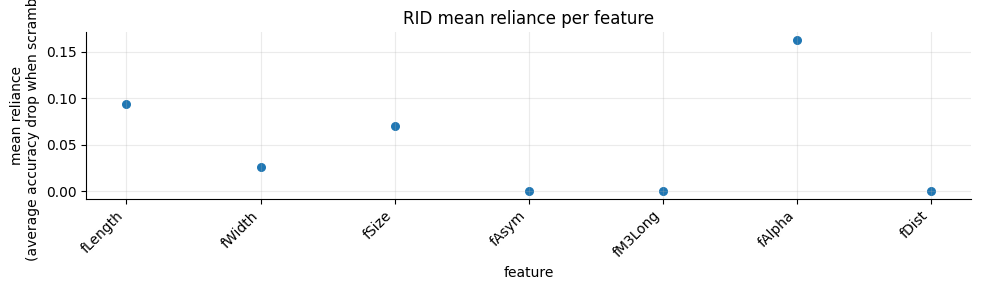

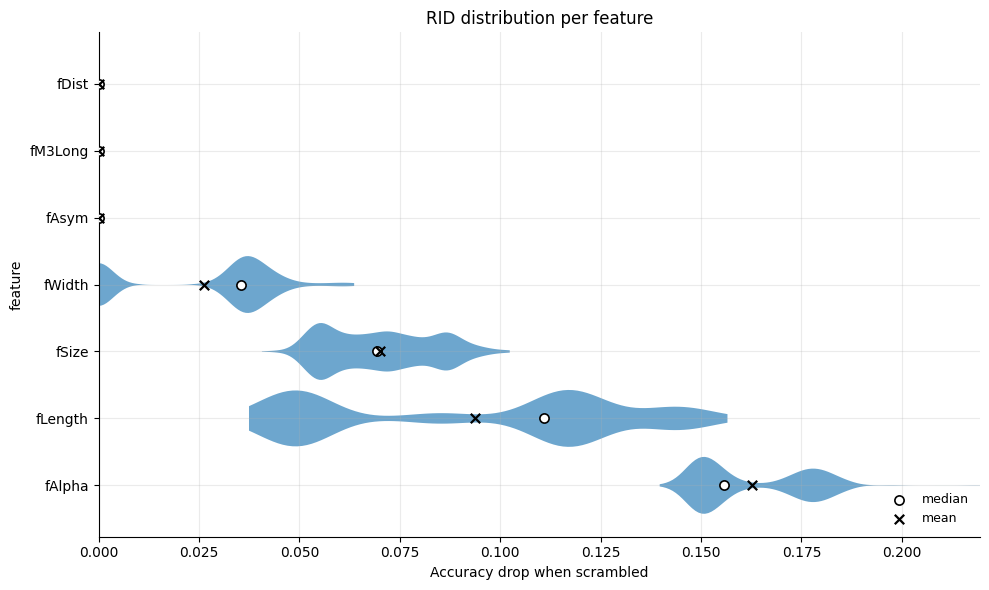

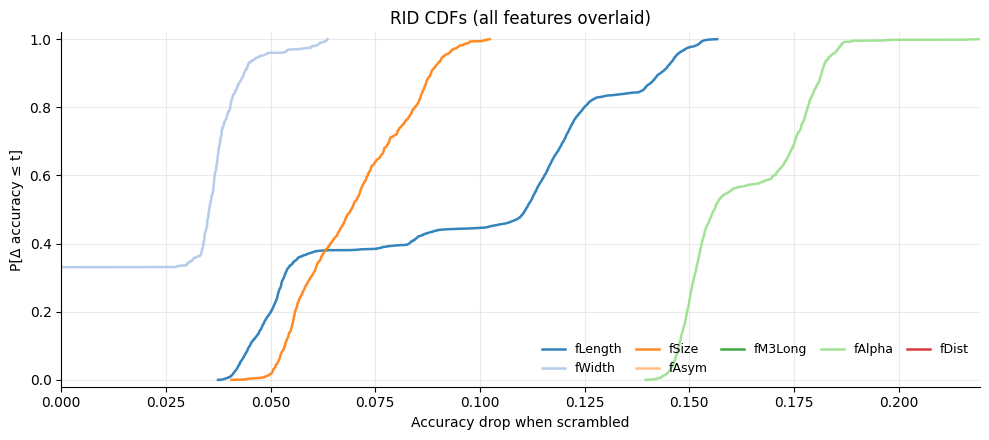

(<Figure size 1000x450 with 1 Axes>,
 <Axes: title={'center': 'RID CDFs (all features overlaid)'}, xlabel='Accuracy drop when scrambled', ylabel='P[Δ accuracy ≤ t]'>)

In [11]:
import numpy as np, pandas as pd
from ucimlrepo import fetch_ucirepo
from praxis import PRAXIS, ThresholdGuessBinarizer

# load MAGIC Gamma Telescope dataset
magic = fetch_ucirepo(id=159)
X_raw = magic.data.features.copy()
y_raw = magic.data.targets.copy()

# gamma or not
y_col = y_raw.columns[0]
y_bin = (y_raw[y_col] == "g").to_numpy(np.int64)

# Threshold Guessing optimality preserving binarization
enc = ThresholdGuessBinarizer(
    n_estimators=100,
    max_depth=1,
    random_state=0,
    column_elimination=True,
)
Xb = enc.fit_transform(X_raw, y_bin).astype(np.uint8)
binning_map = enc.feature_map() # original feature index j maps to the indices of binarized columns derived from j 
print(binning_map)

print("Original X shape:              ", (X_raw.shape[0], X_raw.shape[1]))
print("Binarized X shape:             ", Xb.shape)
print("Number of binarized columns:   ", Xb.shape[1])
print("Number of original variables:  ", len(binning_map))

m = PRAXIS()
m.compute_rid(
    Xb, y_bin,
    n_boot=20,
    lambda_reg=0.01,
    depth_budget=5,
    rashomon_mult=0.01,
    lookahead_k=1,
    seed=0,
    binning_map=binning_map,
)

# important note on feature names: to impose a deterministic order, PRAXIS expects the feature names passed in order of increasing original feature index (i.e. view the binning map as sorted by key and the feature names must pair with that) 
feature_names = [enc.feature_names_in_[j] for j in sorted(binning_map.keys())] # for loop over the original column indices that are used, getting names of that original feature

m.rid_plot_mean(feature_names=feature_names)
m.rid_plot_violin(feature_names=feature_names)
m.rid_plot_cdfs(feature_names=feature_names)



Best objective: 3926Minimum objective: 3926
Rashomon set size: 402823

Root histogram (objective_int, count):
  3926: 16
  3929: 34
  3930: 8
  3931: 8
  3932: 2
  3933: 35
  3934: 6
  3935: 7
  3936: 26
  3937: 16
  3938: 8
  3939: 9
  3940: 40
  3941: 15
  3942: 22
  3943: 50
  3944: 38
  3945: 12
  3946: 52
  3947: 45
  3948: 43
  3949: 67
  3950: 91
  3951: 51
  3952: 76
  3953: 64
  3954: 68
  3955: 104
  3956: 117
  3957: 86
  3958: 106
  3959: 135
  3960: 144
  3961: 71
  3962: 131
  3963: 199
  3964: 96
  3965: 183
  3966: 157
  3967: 127
  3968: 217
  3969: 228
  3970: 228
  3971: 249
  3972: 327
  3973: 262
  3974: 290
  3975: 376
  3976: 362
  3977: 327
  3978: 448
  3979: 313
  3980: 377
  3981: 522
  3982: 467
  3983: 557
  3984: 678
  3985: 605
  3986: 704
  3987: 913
  3988: 596
  3989: 871
  3990: 1021
  3991: 878
  3992: 997
  3993: 916
  3994: 1145
  3995: 1108
  3996: 1110
  3997: 1222
  3998: 1216
  3999: 1465
  4000: 1402
  4001: 1791
  4002: 1446
  4003: 1668
  40

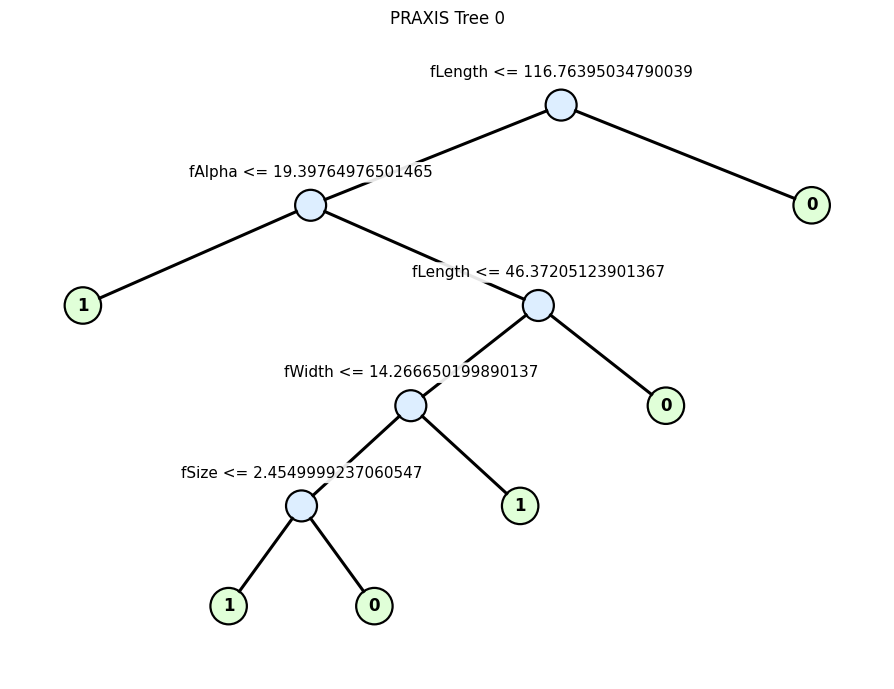


Tree 402822
  Objective (raw):        4044
  Objective (normalized): 0.212618
  Leaves: 7


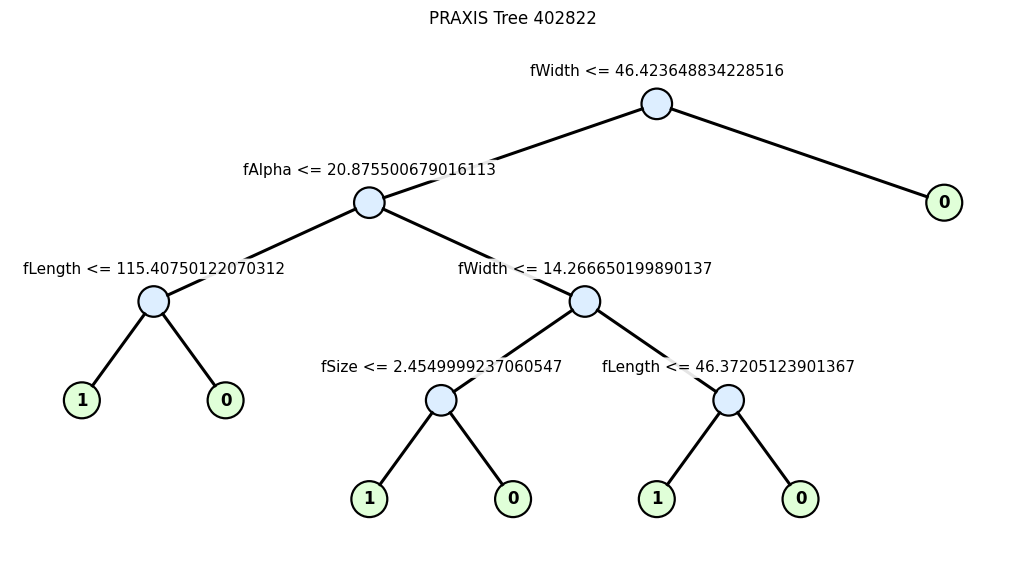

In [12]:

model = PRAXIS()
model.fit(
    Xb, y_bin,
    lambda_reg=0.005,
    depth_budget=5,
    rashomon_mult=0.03,
    multiplicative_slack=0.0,
    key_mode="hash",
    trie_cache_enabled=False,
    lookahead_k=1,
)

print("Minimum objective:", model.get_min_objective())
num_trees = model.count_trees()
print("Rashomon set size:", num_trees)

hist = model.get_root_histogram()
print("\nRoot histogram (objective_int, count):")
for obj, cnt in hist:
    print(f"  {obj}: {cnt}")

tree_indices = [0, num_trees - 1] if num_trees > 1 else [0]
binarized_feature_names = enc.get_feature_names_out() # one per threshold used in the order of the dataset
for tree_idx in tree_indices:
    obj_raw, obj_norm = model.get_tree_objective(tree_idx)
    print("\n" + "=" * 60)
    print(f"Tree {tree_idx}")
    print(f"  Objective (raw):        {obj_raw}")
    print(f"  Objective (normalized): {obj_norm:.6f}")

    paths_str, preds = model.get_tree_paths_str(tree_idx)
    print(f"  Leaves: {len(paths_str)}")

    model.plot_tree(
        tree_idx,
        feature_names=binarized_feature_names,  # one per threshold used in the order of the dataset
        figsize=(14, 6),
        title=f"PRAXIS Tree {tree_idx}"
    )



In [13]:
# multiclass threshold guessing example
import pandas as pd, numpy as np
from praxis import ThresholdGuessBinarizer

df = pd.read_csv("compas_binarized.csv")
X = df.iloc[:, :-1].to_numpy(np.float32)
y_bin = df.iloc[:, -1].to_numpy()

# make a multiclass label for sake of demo
x5 = (X[:, 4] > 0).astype(np.int64)
y = (2 * y_bin.astype(np.int64) + x5).astype(np.int64)

# random feature creation for demo
rng = np.random.default_rng(0)
m, k = X.shape[1], 200
A = np.zeros((m, k), np.float32)
A[rng.integers(0, m, k), np.arange(k)] = 1
A[rng.integers(0, m, k), np.arange(k)] += 1

Z = (X @ A + 0.01 * rng.standard_normal((X.shape[0], k))).astype(np.float32)

enc = ThresholdGuessBinarizer(n_estimators=50, max_depth=1, random_state=0, column_elimination=True)
Zb = enc.fit_transform(Z, y)

print("y classes:", np.unique(y), "counts:", np.bincount(y))
print("Z:", Z.shape, "-> Zb:", Zb.shape, "kept:", enc.n_features_out_)


y classes: [0 1 2 3] counts: [2159  324 1967  516]
Z: (4966, 200) -> Zb: (4966, 115) kept: 115
